In [ ]:
import pandas as pd

df = pd.read_csv("titanic[1].csv")
df.head()

,STRUCTURE,STRUCTURE_ID,ACTION,FREQ,REF_AREA,INDICATOR,SEX,AGE,URBANISATION,UNIT_MEASURE,...,COMP_BREAKDOWN_2_LABEL,COMP_BREAKDOWN_3_LABEL,AGG_METHOD_LABEL,UNIT_TYPE_LABEL,DECIMALS_LABEL,DATABASE_ID_LABEL,TIME_FORMAT_LABEL,UNIT_MULT_LABEL,OBS_STATUS_LABEL,OBS_CONF_LABEL
0,datastructure,WB.DATA360:DS_DATA360(1.2),I,A,SSD,GD_WBL_MAR,_Z,_Z,_Z,SCORE,...,Total,Not Applicable,Not Applicable,Number (real number),Two,"Women, Business and the Law (WBL)",CCYY,Units,Normal value,Public
1,datastructure,WB.DATA360:DS_DATA360(1.2),I,A,SSD,GD_WBL_MAR,_Z,_Z,_Z,SCORE,...,Index component: Is the Law Free of Legal Prov...,Not Applicable,Not Applicable,Number (real number),Two,"Women, Business and the Law (WBL)",CCYY,Units,Normal value,Public
2,datastructure,WB.DATA360:DS_DATA360(1.2),I,A,SSD,GD_WBL_MAR,_Z,_Z,_Z,SCORE,...,Index component: Does the Law Allow a Woman to...,Not Applicable,Not Applicable,Number (real number),Two,"Women, Business and the Law (WBL)",CCYY,Units,Normal value,Public
3,datastructure,WB.DATA360:DS_DATA360(1.2),I,A,SSD,GD_WBL_MAR,_Z,_Z,_Z,SCORE,...,Index component: Does the Law Allow a Woman to...,Not Applicable,Not Applicable,Number (real number),Two,"Women, Business and the Law (WBL)",CCYY,Units,Normal value,Public
4,datastructure,WB.DATA360:DS_DATA360(1.2),I,A,SSD,GD_WBL_MAR,_Z,_Z,_Z,SCORE,...,Index component: Does the Law Grant a Woman th...,Not Applicable,Not Applicable,Number (real number),Two,"Women, Business and the Law (WBL)",CCYY,Units,Normal value,Public


Colab is making it easier than ever to integrate powerful Generative AI capabilities into your projects. We are launching public preview for a simple and intuitive Python library (google.colab.ai) to access state-of-the-art language models directly within Colab environments. All users have free access to most popular LLMs, while paid users have access to a wider selection of models. This means users can spend less time on configuration and set up and more time bringing their ideas to life. With just a few lines of code, you can now perform a variety of tasks:
- Generate text
- Translate languages
- Write creative content
- Categorize text

Happy Coding!


[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/googlecolab/colabtools/blob/main/notebooks/Getting_started_with_google_colab_ai.ipynb)

In [ ]:
# @title List available models
from google.colab import ai

ai.list_models()

['google/gemini-2.0-flash',
 'google/gemini-2.0-flash-lite',
 'google/gemini-2.5-flash',
 'google/gemini-2.5-flash-lite',
 'google/gemini-2.5-pro',
 'google/gemma-3-12b',
 'google/gemma-3-1b',
 'google/gemma-3-27b',
 'google/gemma-3-4b']

Choosing a Model
The model names give you a hint about their capabilities and intended use:

Pro: These are the most capable models, ideal for complex reasoning, creative tasks, and detailed analysis.

Flash: These models are optimized for high speed and efficiency, making them great for summarization, chat applications, and tasks requiring rapid responses.

Gemma: These are lightweight, open-weight models suitable for a variety of text generation tasks and are great for experimentation.

In [ ]:
# @title Simple batch generation example
# Only text-to-text input/output is supported
from google.colab import ai

response = ai.generate_text("What is the capital of France?")
print(response)

The capital of France is **Paris**.



In [ ]:
# @title Choose a different model
from google.colab import ai

response = ai.generate_text("What is the capital of England", model_name='google/gemini-2.0-flash-lite')
print(response)

The capital of England is **London**.



For longer text generations, you can stream the response. This displays the output token by token as it's generated, rather than waiting for the entire response to complete. This provides a more interactive and responsive experience. To enable this, simply set stream=True.

In [ ]:
# @title Simple streaming example
from google.colab import ai

stream = ai.generate_text("Tell me a short story.", stream=True)
for text in stream:
  print(text, end='')

The lighthouse keeper, Silas, was a man of routine. Every night, for fifty years, he'd lit the lamp, a beacon against the treacherous rocks that gnawed at the coastline. The sea was his companion, his enemy, and his only confidante. He knew its moods better than his own.

One stormy night, the wind howled like a banshee. The waves crashed against the tower, shaking it to its core. Silas, clinging to the railing, felt a fear he hadn't experienced in decades. This wasn't just a storm; this was a monster.

Suddenly, a small, wooden boat, tossed about like a toy, appeared in the raging sea. He squinted, his heart leaping into his throat. A child. Alone.

Ignoring the raging tempest, Silas raced down the winding stairs, his old bones protesting with every step. He launched his small rescue boat, a fragile craft against the fury of the storm.

Fighting the waves, he reached the child. A girl, no older than seven, clung to the wreckage, her face white with terror. With a strength born of desp

In [ ]:
#@title Text formatting setup
#code is not necessary for colab.ai, but is useful in fomatting text chunks
import sys

class LineWrapper:
    def __init__(self, max_length=80):
        self.max_length = max_length
        self.current_line_length = 0

    def print(self, text_chunk):
        i = 0
        n = len(text_chunk)
        while i < n:
            start_index = i
            while i < n and text_chunk[i] not in ' \n': # Find end of word
                i += 1
            current_word = text_chunk[start_index:i]

            delimiter = ""
            if i < n: # If not end of chunk, we found a delimiter
                delimiter = text_chunk[i]
                i += 1 # Consume delimiter

            if current_word:
                needs_leading_space = (self.current_line_length > 0)

                # Case 1: Word itself is too long for a line (must be broken)
                if len(current_word) > self.max_length:
                    if needs_leading_space: # Newline if current line has content
                        sys.stdout.write('\n')
                        self.current_line_length = 0
                    for char_val in current_word: # Break the long word
                        if self.current_line_length >= self.max_length:
                            sys.stdout.write('\n')
                            self.current_line_length = 0
                        sys.stdout.write(char_val)
                        self.current_line_length += 1
                # Case 2: Word doesn't fit on current line (print on new line)
                elif self.current_line_length + (1 if needs_leading_space else 0) + len(current_word) > self.max_length:
                    sys.stdout.write('\n')
                    sys.stdout.write(current_word)
                    self.current_line_length = len(current_word)
                # Case 3: Word fits on current line
                else:
                    if needs_leading_space:
                        # Define punctuation that should not have a leading space
                        # when they form an entire "word" (token) following another word.
                        no_leading_space_punctuation = {
                            ",", ".", ";", ":", "!", "?",        # Standard sentence punctuation
                            ")", "]", "}",                     # Closing brackets
                            "'s", "'S", "'re", "'RE", "'ve", "'VE", # Common contractions
                            "'m", "'M", "'ll", "'LL", "'d", "'D",
                            "n't", "N'T",
                            "...", "…"                          # Ellipses
                        }
                        if current_word not in no_leading_space_punctuation:
                            sys.stdout.write(' ')
                            self.current_line_length += 1
                    sys.stdout.write(current_word)
                    self.current_line_length += len(current_word)

            if delimiter == '\n':
                sys.stdout.write('\n')
                self.current_line_length = 0
            elif delimiter == ' ':
                # If line is full and a space delimiter arrives, it implies a wrap.
                if self.current_line_length >= self.max_length:
                    sys.stdout.write('\n')
                    self.current_line_length = 0

        sys.stdout.flush()


In [ ]:
# @title Formatted streaming example
from google.colab import ai

wrapper = LineWrapper()
for chunk in ai.generate_text('Give me a long winded description about the evolution of the Roman Empire.', model_name='google/gemini-2.0-flash', stream=True):
  wrapper.print(chunk)

Alright, settle in, because the Roman Empire’s evolution wasn't a tidy, linear
process. It was a centuries-long, tumultuous transformation, marked by
breathtaking innovation, brutal power struggles, and a slow, creeping societal
decay. We're talking about a journey from a humble city-state in the Italian
peninsula to a sprawling, multifaceted empire that left an indelible mark on
law, language, architecture, governance, and even our very understanding of the
world.

It all began, as legend would have it, with Romulus and Remus, twin brothers
raised by a she-wolf, who founded the city of Rome in 753 BCE. Now, that’s just
a legend, but it serves to highlight the foundational spirit of Rome: ambition,
strength, and a certain ruthlessness. Initially, Rome was ruled by a monarchy, a
system eventually deemed unsatisfactory by the powerful patrician class. This
led to the **Roman Republic**, established around 509 BCE, a watershed moment
that would define the early character of Rome.

The Rep

In [1]:
import pandas as pd

In [ ]:
import pandas as pd

In [ ]:
print(df.std(numeric_only=True)

In [2]:
import pandas as pd
path=r'C:\Users\ANTLEY SHRUBAN\Downloads\archive\your_file_name.csv' # Example: change 'your_file_name.csv' to the actual CSV file name
df=pd.read_csv(path)

SyntaxError: invalid syntax (1970199636.py, line 2)

In [3]:
import panda as pd

ModuleNotFoundError: No module named 'panda'

In [4]:
import pandas as pd

path= r'C:\Users\ANTLEY SHRUBAN\Downloads\archive\your_file_name.csv' # Replace 'your_file_name.csv' with the actual CSV file name
df= pd.read_csv(path)

SyntaxError: (unicode error) 'unicodeescape' codec can't decode bytes in position 2-3: truncated \UXXXXXXXX escape (673505932.py, line 3)

In [5]:
print(df.isnull())

NameError: name 'df' is not defined

age_analysis=df.groupby("Survived"["Age"].mean())

In [6]:
age_analysis=df.groupby("Survived")["Age"].mean()

NameError: name 'df' is not defined

In [7]:
age_analysis=df.groupby("Survived")["Age"].mean()
print("\nAverage age of survivors vs. non-Survivors:")
print(age_analysis)

NameError: name 'df' is not defined

In [8]:
import pandas as pd
url=/content/GD_WBL_MAR.csv

SyntaxError: invalid syntax (2787073611.py, line 2)

In [ ]:
import pandas as pd
url=/content/GD_WBL_MAR.csv

SyntaxError: invalid syntax (2787073611.py, line 2)

import pandas as pd
ur

In [ ]:
import pandas as pd
url=/content/GD_WBL_MAR.csv

SyntaxError: invalid syntax (2787073611.py, line 2)

In [9]:
import pandas as pd

df = pd.read_csv("GD_WBL_MAR.csv")
df.head()

,STRUCTURE,STRUCTURE_ID,ACTION,FREQ,REF_AREA,INDICATOR,SEX,AGE,URBANISATION,UNIT_MEASURE,...,COMP_BREAKDOWN_2_LABEL,COMP_BREAKDOWN_3_LABEL,AGG_METHOD_LABEL,UNIT_TYPE_LABEL,DECIMALS_LABEL,DATABASE_ID_LABEL,TIME_FORMAT_LABEL,UNIT_MULT_LABEL,OBS_STATUS_LABEL,OBS_CONF_LABEL
0,datastructure,WB.DATA360:DS_DATA360(1.2),I,A,SSD,GD_WBL_MAR,_Z,_Z,_Z,SCORE,...,Total,Not Applicable,Not Applicable,Number (real number),Two,"Women, Business and the Law (WBL)",CCYY,Units,Normal value,Public
1,datastructure,WB.DATA360:DS_DATA360(1.2),I,A,SSD,GD_WBL_MAR,_Z,_Z,_Z,SCORE,...,Index component: Is the Law Free of Legal Prov...,Not Applicable,Not Applicable,Number (real number),Two,"Women, Business and the Law (WBL)",CCYY,Units,Normal value,Public
2,datastructure,WB.DATA360:DS_DATA360(1.2),I,A,SSD,GD_WBL_MAR,_Z,_Z,_Z,SCORE,...,Index component: Does the Law Allow a Woman to...,Not Applicable,Not Applicable,Number (real number),Two,"Women, Business and the Law (WBL)",CCYY,Units,Normal value,Public
3,datastructure,WB.DATA360:DS_DATA360(1.2),I,A,SSD,GD_WBL_MAR,_Z,_Z,_Z,SCORE,...,Index component: Does the Law Allow a Woman to...,Not Applicable,Not Applicable,Number (real number),Two,"Women, Business and the Law (WBL)",CCYY,Units,Normal value,Public
4,datastructure,WB.DATA360:DS_DATA360(1.2),I,A,SSD,GD_WBL_MAR,_Z,_Z,_Z,SCORE,...,Index component: Does the Law Grant a Woman th...,Not Applicable,Not Applicable,Number (real number),Two,"Women, Business and the Law (WBL)",CCYY,Units,Normal value,Public


In [10]:
df.columns

Index(['STRUCTURE', 'STRUCTURE_ID', 'ACTION', 'FREQ', 'REF_AREA', 'INDICATOR',
       'SEX', 'AGE', 'URBANISATION', 'UNIT_MEASURE', 'COMP_BREAKDOWN_1',
       'COMP_BREAKDOWN_2', 'COMP_BREAKDOWN_3', 'TIME_PERIOD', 'OBS_VALUE',
       'AGG_METHOD', 'UNIT_TYPE', 'DECIMALS', 'DATABASE_ID', 'TIME_FORMAT',
       'UNIT_MULT', 'OBS_STATUS', 'OBS_CONF', 'FREQ_LABEL', 'REF_AREA_LABEL',
       'INDICATOR_LABEL', 'SEX_LABEL', 'AGE_LABEL', 'URBANISATION_LABEL',
       'UNIT_MEASURE_LABEL', 'COMP_BREAKDOWN_1_LABEL',
       'COMP_BREAKDOWN_2_LABEL', 'COMP_BREAKDOWN_3_LABEL', 'AGG_METHOD_LABEL',
       'UNIT_TYPE_LABEL', 'DECIMALS_LABEL', 'DATABASE_ID_LABEL',
       'TIME_FORMAT_LABEL', 'UNIT_MULT_LABEL', 'OBS_STATUS_LABEL',
       'OBS_CONF_LABEL'],
      dtype='object')

In [11]:
df.types

AttributeError: 'DataFrame' object has no attribute 'types'

In [12]:
df.count

<bound method DataFrame.count of           STRUCTURE                STRUCTURE_ID ACTION FREQ REF_AREA  \
0     datastructure  WB.DATA360:DS_DATA360(1.2)      I    A      SSD   
1     datastructure  WB.DATA360:DS_DATA360(1.2)      I    A      SSD   
2     datastructure  WB.DATA360:DS_DATA360(1.2)      I    A      SSD   
3     datastructure  WB.DATA360:DS_DATA360(1.2)      I    A      SSD   
4     datastructure  WB.DATA360:DS_DATA360(1.2)      I    A      SSD   
...             ...                         ...    ...  ...      ...   
3010  datastructure  WB.DATA360:DS_DATA360(1.2)      I    A      SRB   
3011  datastructure  WB.DATA360:DS_DATA360(1.2)      I    A      SRB   
3012  datastructure  WB.DATA360:DS_DATA360(1.2)      I    A      SRB   
3013  datastructure  WB.DATA360:DS_DATA360(1.2)      I    A      SRB   
3014  datastructure  WB.DATA360:DS_DATA360(1.2)      I    A      SRB   

       INDICATOR SEX AGE URBANISATION UNIT_MEASURE  ...  \
0     GD_WBL_MAR  _Z  _Z           _Z        SCORE  ...   
1     GD_WBL_MAR  _Z  _Z           _Z        SCORE  ...   
2     GD_WBL_MAR  _Z  _Z           _Z        SCORE  ...   
3     GD_WBL_MAR  _Z  _Z           _Z        SCORE  ...   
4     GD_WBL_MAR  _Z  _Z           _Z        SCORE  ...   
...          ...  ..  ..          ...          ...  ...   
3010  GD_WBL_MAR  _Z  _Z           _Z        SCORE  ...   
3011  GD_WBL_MAR  _Z  _Z           _Z        SCORE  ...   
3012  GD_WBL_MAR  _Z  _Z           _Z        SCORE  ...   
3013  GD_WBL_MAR  _Z  _Z           _Z        SCORE  ...   
3014  GD_WBL_MAR  _Z  _Z           _Z        SCORE  ...   

                                 COMP_BREAKDOWN_2_LABEL  \
0                                                 Total   
1     Index component: Is the Law Free of Legal Prov...   
2     Index component: Does the Law Allow a Woman to...   
3     Index component: Does the Law Allow a Woman to...   
4     Index component: Does the Law Grant a Woman th...   
...                                                 ...   
3010                                              Total   
3011  Index component: In Your Opinion, To What Exte...   
3012  Index component: In Your Opinion, To What Exte...   
3013  Index component: In Your Opinion, To What Exte...   
3014  Index component: In Your Opinion, To What Exte...   

     COMP_BREAKDOWN_3_LABEL AGG_METHOD_LABEL       UNIT_TYPE_LABEL  \
0            Not Applicable   Not Applicable  Number (real number)   
1            Not Applicable   Not Applicable  Number (real number)   
2            Not Applicable   Not Applicable  Number (real number)   
3            Not Applicable   Not Applicable  Number (real number)   
4            Not Applicable   Not Applicable  Number (real number)   
...                     ...              ...                   ...   
3010         Not Applicable   Not Applicable  Number (real number)   
3011         Not Applicable   Not Applicable  Number (real number)   
3012         Not Applicable   Not Applicable  Number (real number)   
3013         Not Applicable   Not Applicable  Number (real number)   
3014         Not Applicable   Not Applicable  Number (real number)   

     DECIMALS_LABEL                  DATABASE_ID_LABEL TIME_FORMAT_LABEL  \
0               Two  Women, Business and the Law (WBL)              CCYY   
1               Two  Women, Business and the Law (WBL)              CCYY   
2               Two  Women, Business and the Law (WBL)              CCYY   
3               Two  Women, Business and the Law (WBL)              CCYY   
4               Two  Women, Business and the Law (WBL)              CCYY   
...             ...                                ...               ...   
3010            Two  Women, Business and the Law (WBL)              CCYY   
3011            Two  Women, Business and the Law (WBL)              CCYY   
3012            Two  Women, Business and the Law (WBL)              CCYY   
3013            Two  Women, Business and the Law (WBL)              CCYY   
3014   

In [ ]:
age_analsis=dfgroupby("Survived")["Age"]

In [ ]:
age_analysis=df.groupby("Survived")["Age"].mean()
print("\nAverage age of survivors vs. non-Survivors:")
print(age_analysis)

NameError: name 'df' is not defined

In [13]:
df.groupby("REF_AREA").size()

,0
REF_AREA,
AFG,15
AGO,15
ALB,15
ARE,15
ARG,15
...,...
XKX,15
YEM,15
ZAF,15


In [14]:
df.groupby("REF_AREA").size().reset_index(name="count")

,REF_AREA,count
0,AFG,15
1,AGO,15
2,ALB,15
3,ARE,15
4,ARG,15
...,...,...
196,XKX,15
197,YEM,15
198,ZAF,15
199,ZMB,15


In [15]:
df.groupby("INDICATOR").size()

,0
INDICATOR,
GD_WBL_MAR,3015


In [16]:
counts.plot(kind="bar")

plt.title("Country Comparison")
plt.xlabel("Country Code")
plt.ylabel("Number of Records")

plt.show()

NameError: name 'counts' is not defined

In [17]:
import pandas as pd
import matplotlib.pyplot as plt

In [18]:
import pandas as pd
import matplotlib.pyplot as plt

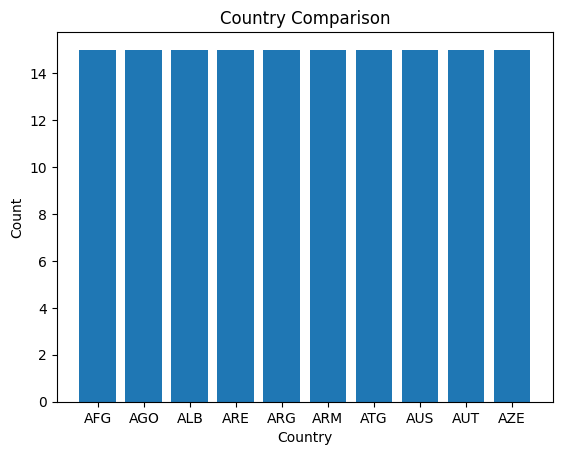

In [19]:
counts = df.groupby("REF_AREA").size()

plt.bar(counts.index[:10], counts.values[:10])

plt.title("Country Comparison")
plt.xlabel("Country")
plt.ylabel("Count")

plt.show()

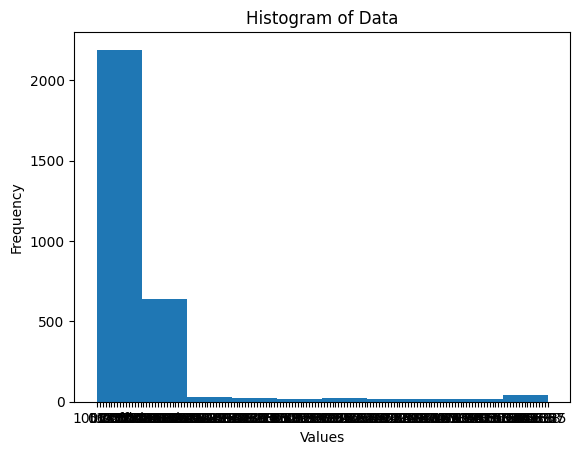

In [20]:
import matplotlib.pyplot as plt

plt.hist(df["OBS_VALUE"], bins=10)
plt.xlabel("Values")
plt.ylabel("Frequency")
plt.title("Histogram of Data")
plt.show()

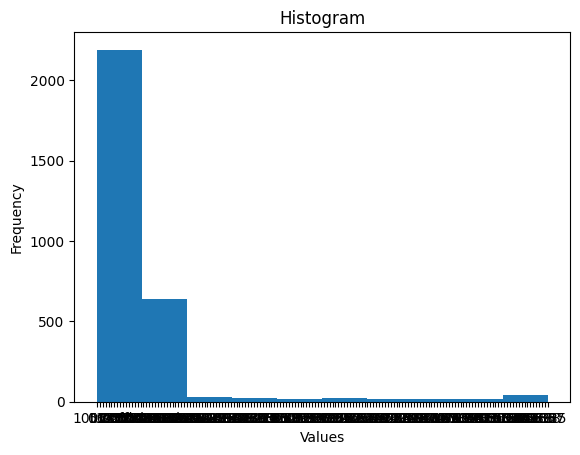

In [21]:
import matplotlib.pyplot as plt

plt.hist(df["OBS_VALUE"], bins=10)

plt.title("Histogram")
plt.xlabel("Values")
plt.ylabel("Frequency")

plt.show()

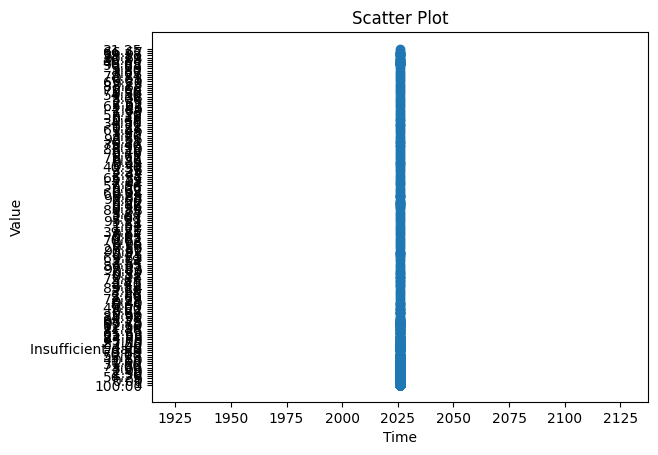

In [22]:
import matplotlib.pyplot as plt

plt.scatter(df["TIME_PERIOD"], df["OBS_VALUE"])

plt.title("Scatter Plot")
plt.xlabel("Time")
plt.ylabel("Value")

plt.show()

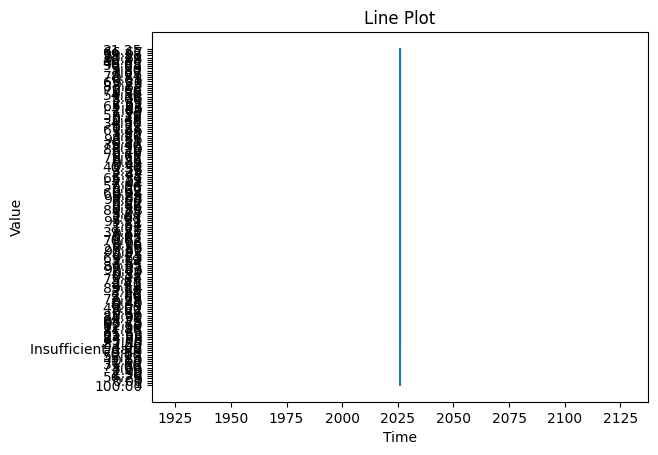

In [23]:
import matplotlib.pyplot as plt

plt.plot(df["TIME_PERIOD"], df["OBS_VALUE"])

plt.title("Line Plot")
plt.xlabel("Time")
plt.ylabel("Value")

plt.show()

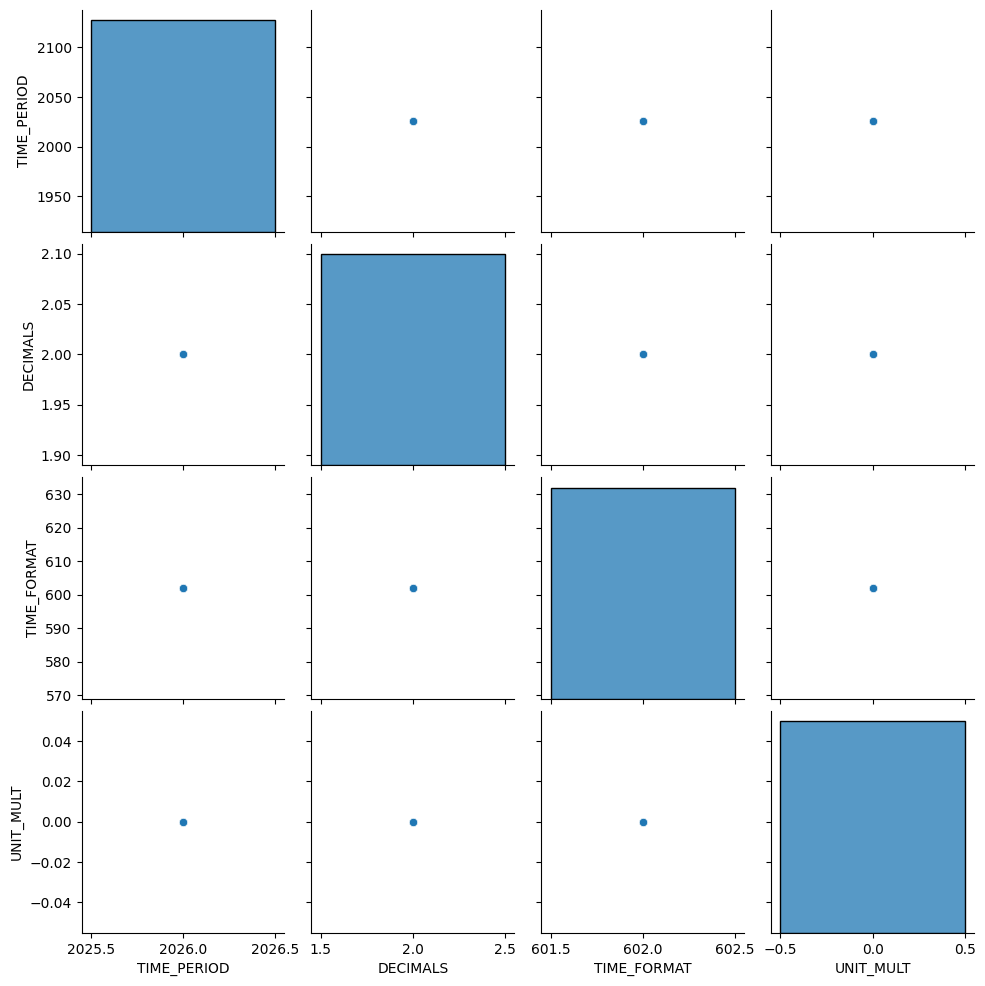

In [24]:
import seaborn as sns

sns.pairplot(df)

plt.show()

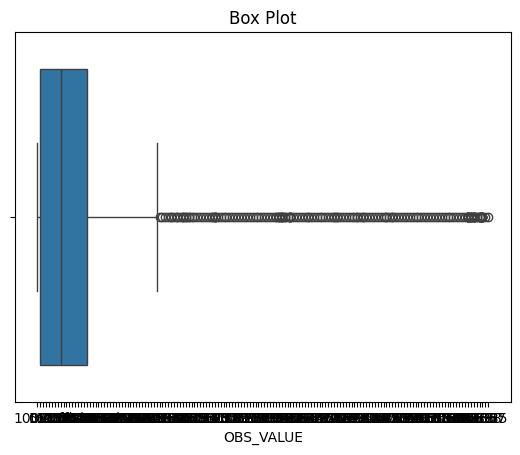

In [25]:
import seaborn as sns

sns.boxplot(x=df["OBS_VALUE"])

plt.title("Box Plot")

plt.show()

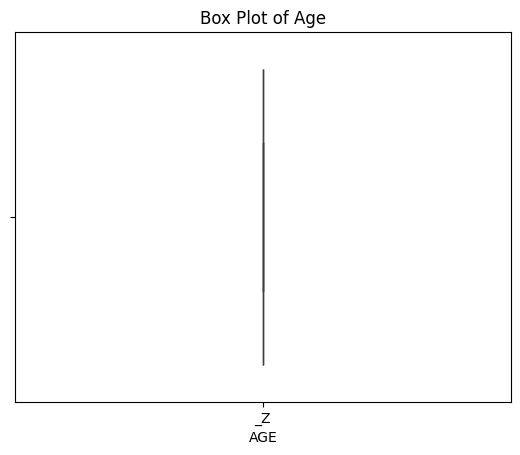

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x=df["AGE"])

plt.title("Box Plot of Age")

plt.show()

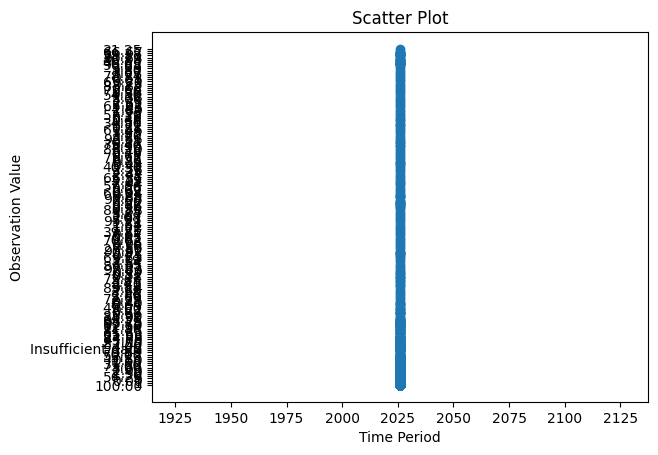

In [27]:
import matplotlib.pyplot as plt

plt.scatter(df["TIME_PERIOD"], df["OBS_VALUE"])

plt.title("Scatter Plot")
plt.xlabel("Time Period")
plt.ylabel("Observation Value")

plt.show()

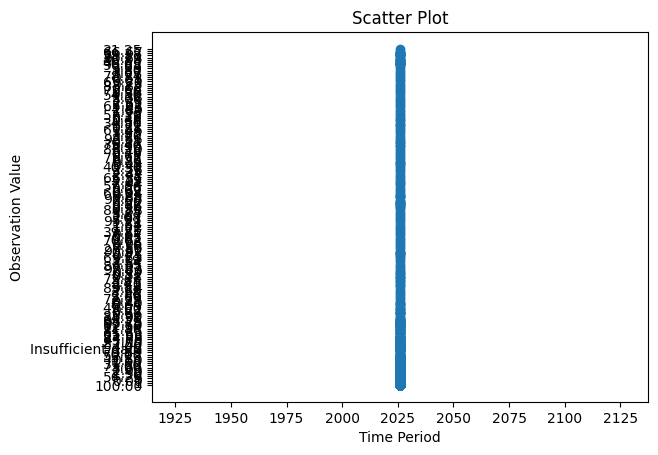

In [28]:
import matplotlib.pyplot as plt

plt.scatter(df["TIME_PERIOD"], df["OBS_VALUE"])

plt.title("Scatter Plot")
plt.xlabel("Time Period")
plt.ylabel("Observation Value")

plt.show()

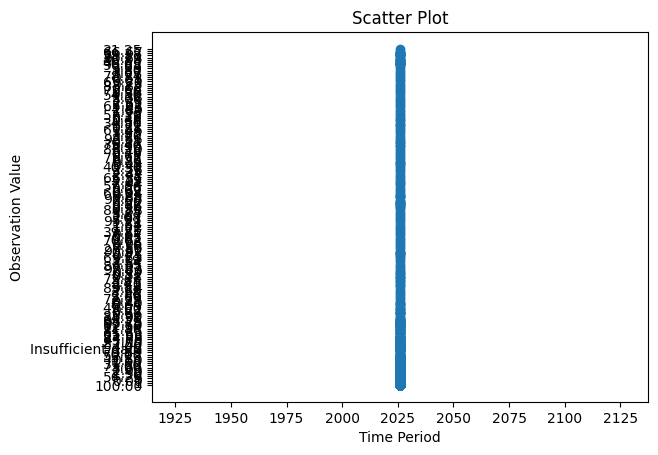

In [29]:
import matplotlib.pyplot as plt

plt.scatter(df["TIME_PERIOD"], df["OBS_VALUE"])

plt.title("Scatter Plot")
plt.xlabel("Time Period")
plt.ylabel("Observation Value")

plt.show()

In [30]:
pivot = df.pivot_table(index="REF_AREA", columns="INDICATOR", values="OBS_VALUE")

sns.heatmap(pivot)

plt.title("Heatmap of Country vs Indicator")

plt.show()

TypeError: agg function failed [how->mean,dtype->object]

/usr/local/lib/python3.12/dist-packages/seaborn/matrix.py:202: RuntimeWarning: All-NaN slice encountered
  vmin = np.nanmin(calc_data)
/usr/local/lib/python3.12/dist-packages/seaborn/matrix.py:207: RuntimeWarning: All-NaN slice encountered
  vmax = np.nanmax(calc_data)


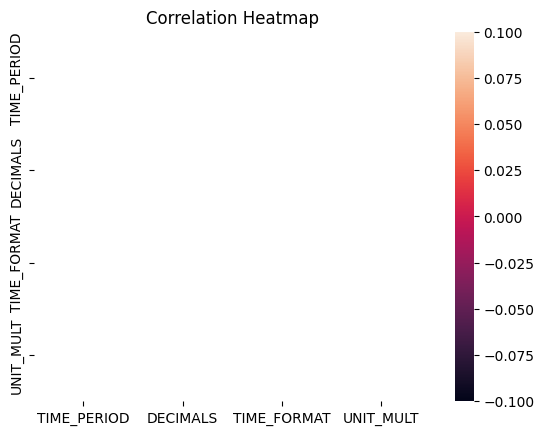

In [31]:
corr = df.corr(numeric_only=True)

sns.heatmap(corr, annot=True)

plt.title("Correlation Heatmap")

plt.show()

/usr/local/lib/python3.12/dist-packages/seaborn/matrix.py:202: RuntimeWarning: All-NaN slice encountered
  vmin = np.nanmin(calc_data)
/usr/local/lib/python3.12/dist-packages/seaborn/matrix.py:207: RuntimeWarning: All-NaN slice encountered
  vmax = np.nanmax(calc_data)


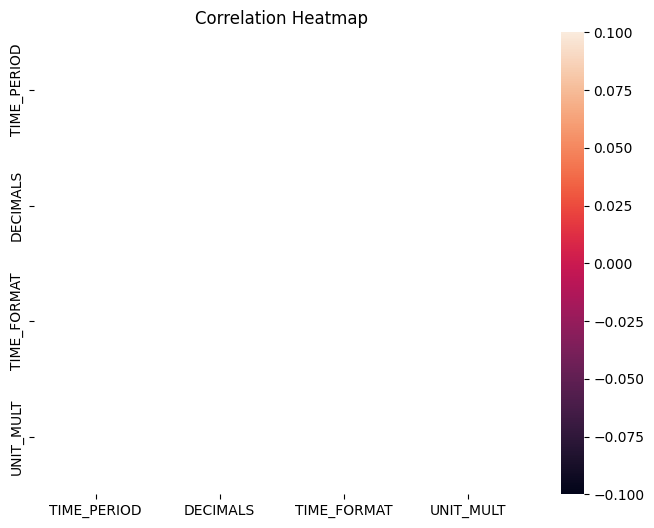

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

sns.heatmap(corr, annot=True)

plt.title("Correlation Heatmap")

plt.show()

In [ ]:
import pandas as pd

df = pd.read_csv("titanic[1].csv")
df.head()

,STRUCTURE,STRUCTURE_ID,ACTION,FREQ,REF_AREA,INDICATOR,SEX,AGE,URBANISATION,UNIT_MEASURE,...,COMP_BREAKDOWN_2_LABEL,COMP_BREAKDOWN_3_LABEL,AGG_METHOD_LABEL,UNIT_TYPE_LABEL,DECIMALS_LABEL,DATABASE_ID_LABEL,TIME_FORMAT_LABEL,UNIT_MULT_LABEL,OBS_STATUS_LABEL,OBS_CONF_LABEL
0,datastructure,WB.DATA360:DS_DATA360(1.2),I,A,SSD,GD_WBL_MAR,_Z,_Z,_Z,SCORE,...,Total,Not Applicable,Not Applicable,Number (real number),Two,"Women, Business and the Law (WBL)",CCYY,Units,Normal value,Public
1,datastructure,WB.DATA360:DS_DATA360(1.2),I,A,SSD,GD_WBL_MAR,_Z,_Z,_Z,SCORE,...,Index component: Is the Law Free of Legal Prov...,Not Applicable,Not Applicable,Number (real number),Two,"Women, Business and the Law (WBL)",CCYY,Units,Normal value,Public
2,datastructure,WB.DATA360:DS_DATA360(1.2),I,A,SSD,GD_WBL_MAR,_Z,_Z,_Z,SCORE,...,Index component: Does the Law Allow a Woman to...,Not Applicable,Not Applicable,Number (real number),Two,"Women, Business and the Law (WBL)",CCYY,Units,Normal value,Public
3,datastructure,WB.DATA360:DS_DATA360(1.2),I,A,SSD,GD_WBL_MAR,_Z,_Z,_Z,SCORE,...,Index component: Does the Law Allow a Woman to...,Not Applicable,Not Applicable,Number (real number),Two,"Women, Business and the Law (WBL)",CCYY,Units,Normal value,Public
4,datastructure,WB.DATA360:DS_DATA360(1.2),I,A,SSD,GD_WBL_MAR,_Z,_Z,_Z,SCORE,...,Index component: Does the Law Grant a Woman th...,Not Applicable,Not Applicable,Number (real number),Two,"Women, Business and the Law (WBL)",CCYY,Units,Normal value,Public


In [34]:
import pandas as pd
df=pd.read_csv("titanic[1].csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


,STRUCTURE,STRUCTURE_ID,ACTION,FREQ,REF_AREA,INDICATOR,SEX,AGE,URBANISATION,UNIT_MEASURE,...,COMP_BREAKDOWN_2_LABEL,COMP_BREAKDOWN_3_LABEL,AGG_METHOD_LABEL,UNIT_TYPE_LABEL,DECIMALS_LABEL,DATABASE_ID_LABEL,TIME_FORMAT_LABEL,UNIT_MULT_LABEL,OBS_STATUS_LABEL,OBS_CONF_LABEL
0,datastructure,WB.DATA360:DS_DATA360(1.2),I,A,SSD,GD_WBL_MAR,_Z,_Z,_Z,SCORE,...,Total,Not Applicable,Not Applicable,Number (real number),Two,"Women, Business and the Law (WBL)",CCYY,Units,Normal value,Public
1,datastructure,WB.DATA360:DS_DATA360(1.2),I,A,SSD,GD_WBL_MAR,_Z,_Z,_Z,SCORE,...,Index component: Is the Law Free of Legal Prov...,Not Applicable,Not Applicable,Number (real number),Two,"Women, Business and the Law (WBL)",CCYY,Units,Normal value,Public
2,datastructure,WB.DATA360:DS_DATA360(1.2),I,A,SSD,GD_WBL_MAR,_Z,_Z,_Z,SCORE,...,Index component: Does the Law Allow a Woman to...,Not Applicable,Not Applicable,Number (real number),Two,"Women, Business and the Law (WBL)",CCYY,Units,Normal value,Public
3,datastructure,WB.DATA360:DS_DATA360(1.2),I,A,SSD,GD_WBL_MAR,_Z,_Z,_Z,SCORE,...,Index component: Does the Law Allow a Woman to...,Not Applicable,Not Applicable,Number (real number),Two,"Women, Business and the Law (WBL)",CCYY,Units,Normal value,Public
4,datastructure,WB.DATA360:DS_DATA360(1.2),I,A,SSD,GD_WBL_MAR,_Z,_Z,_Z,SCORE,...,Index component: Does the Law Grant a Woman th...,Not Applicable,Not Applicable,Number (real number),Two,"Women, Business and the Law (WBL)",CCYY,Units,Normal value,Public


In [35]:
import pandas as pd
df=pd.read_csv("titanic[1].csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [36]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=df)

MessageError: Error: credential propagation was unsuccessful

In [37]:
import pandas as pd
df=pd.read_csv("titanic[1].csv")
df.head()
df.sex()
df.Age()

AttributeError: 'DataFrame' object has no attribute 'sex'

In [38]:
import pandas as pd
df=pd.read_csv("titanic[1].csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


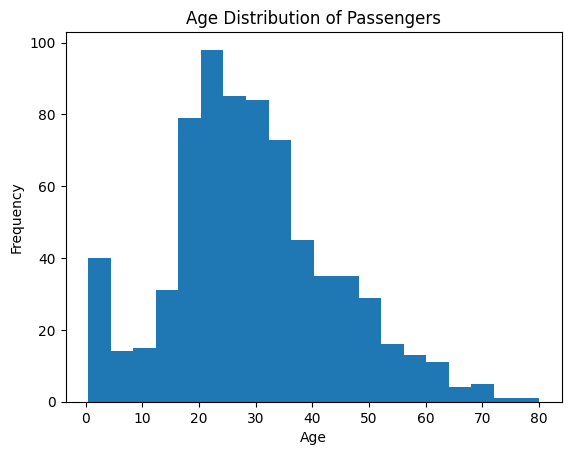

In [39]:
plt.hist(df["Age"].dropna(), bins=20)

plt.title("Age Distribution of Passengers")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

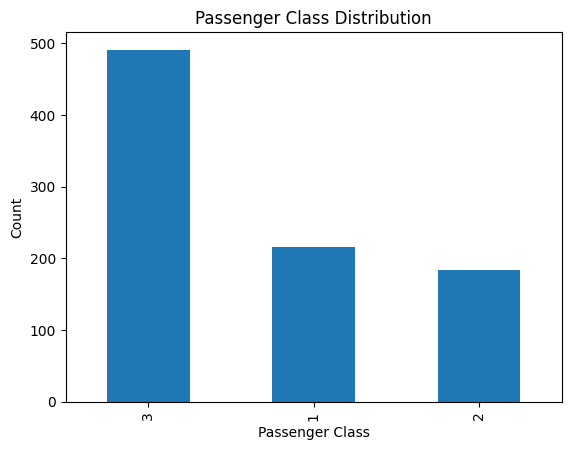

In [40]:
df["Pclass"].value_counts().plot(kind="bar")

plt.title("Passenger Class Distribution")
plt.xlabel("Passenger Class")
plt.ylabel("Count")

plt.show()

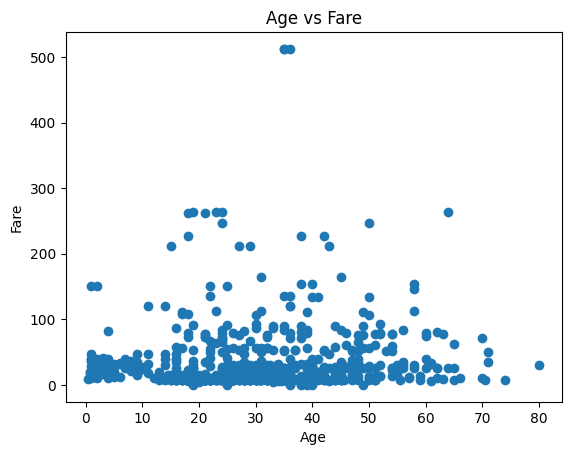

In [41]:
plt.scatter(df["Age"], df["Fare"])

plt.title("Age vs Fare")
plt.xlabel("Age")
plt.ylabel("Fare")

plt.show()

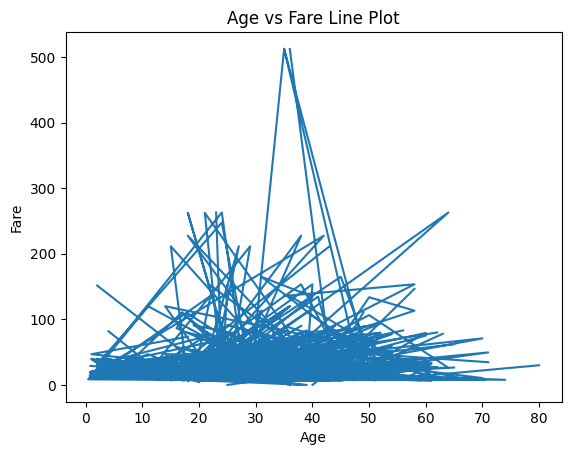

In [42]:
plt.plot(df["Age"], df["Fare"])

plt.title("Age vs Fare Line Plot")
plt.xlabel("Age")
plt.ylabel("Fare")

plt.show()

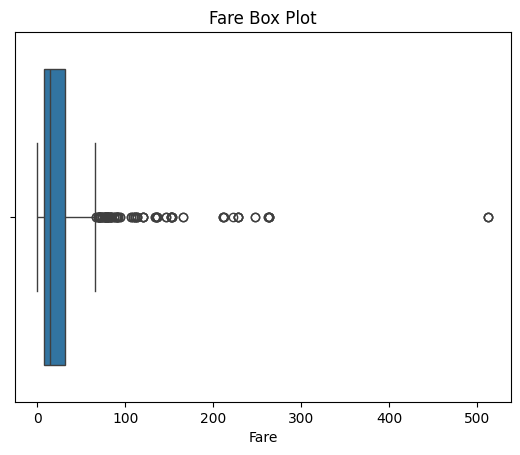

In [43]:
sns.boxplot(x=df["Fare"])

plt.title("Fare Box Plot")

plt.show()

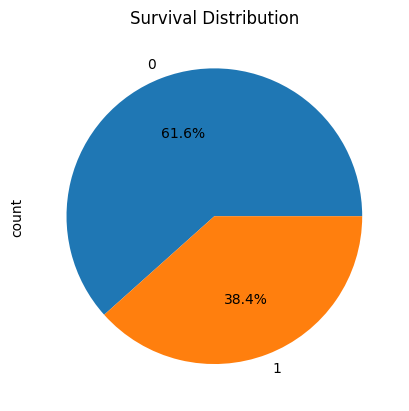

In [44]:
df["Survived"].value_counts().plot(kind="pie", autopct='%1.1f%%')

plt.title("Survival Distribution")

plt.show()

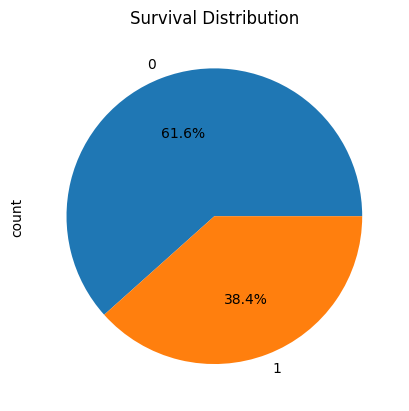

In [45]:
df["Survived"].value_counts().plot(kind="pie", autopct='%1.1f%%')

plt.title("Survival Distribution")

plt.show()

In [46]:
print("1. Histogram (Age):")
print("The histogram shows that most passengers were between 20 and 40 years old, indicating that the majority of passengers were young adults.")

print("\n2. Bar Graph (Passenger Class):")
print("The bar graph shows that most passengers traveled in 3rd class, while fewer passengers were in 1st and 2nd class.")

print("\n3. Scatter Plot (Age vs Fare):")
print("The scatter plot indicates no strong relationship between age and fare, but higher fares are mostly associated with some passengers.")

print("\n4. Box Plot (Fare):")
print("The box plot shows that most passengers paid lower fares, while a few passengers paid very high fares, indicating the presence of outliers.")

print("\n5. Pie Chart (Survival):")
print("The pie chart shows that a larger portion of passengers did not survive compared to those who survived.")

1. Histogram (Age):
The histogram shows that most passengers were between 20 and 40 years old, indicating that the majority of passengers were young adults.

2. Bar Graph (Passenger Class):
The bar graph shows that most passengers traveled in 3rd class, while fewer passengers were in 1st and 2nd class.

3. Scatter Plot (Age vs Fare):
The scatter plot indicates no strong relationship between age and fare, but higher fares are mostly associated with some passengers.

4. Box Plot (Fare):
The box plot shows that most passengers paid lower fares, while a few passengers paid very high fares, indicating the presence of outliers.

5. Pie Chart (Survival):
The pie chart shows that a larger portion of passengers did not survive compared to those who survived.


In [47]:
from IPython.display import Markdown, display

display(Markdown("""
### Final Graph Interpretations

**1. Histogram (Age Distribution)**
Most passengers were between **20 and 40 years old**, indicating that the majority of travelers were young adults.

**2. Bar Graph (Passenger Class Distribution)**
The bar graph shows that **3rd class had the highest number of passengers**, suggesting that most passengers belonged to the lower passenger class.

**3. Scatter Plot (Age vs Fare)**
The scatter plot indicates **no strong relationship between age and fare**, although higher fares are mostly associated with first-class passengers.

**4. Line Plot (Age vs Fare Trend)**
The line plot shows **variations in ticket fare across different ages**, but there is **no consistent trend** between age and fare.

**5. Box Plot (Fare Distribution)**
The box plot reveals that **most passengers paid lower fares**, while a few passengers paid **very high fares**, indicating outliers.

**6. Pie Chart (Survival Distribution)**
The pie chart shows that **a larger percentage of passengers did not survive compared to those who survived**.
"""))


### Final Graph Interpretations

**1. Histogram (Age Distribution)**  
Most passengers were between **20 and 40 years old**, indicating that the majority of travelers were young adults.

**2. Bar Graph (Passenger Class Distribution)**  
The bar graph shows that **3rd class had the highest number of passengers**, suggesting that most passengers belonged to the lower passenger class.

**3. Scatter Plot (Age vs Fare)**  
The scatter plot indicates **no strong relationship between age and fare**, although higher fares are mostly associated with first-class passengers.

**4. Line Plot (Age vs Fare Trend)**  
The line plot shows **variations in ticket fare across different ages**, but there is **no consistent trend** between age and fare.

**5. Box Plot (Fare Distribution)**  
The box plot reveals that **most passengers paid lower fares**, while a few passengers paid **very high fares**, indicating outliers.

**6. Pie Chart (Survival Distribution)**  
The pie chart shows that **a larger percentage of passengers did not survive compared to those who survived**.


/usr/local/lib/python3.12/dist-packages/seaborn/matrix.py:202: RuntimeWarning: All-NaN slice encountered
  vmin = np.nanmin(calc_data)
/usr/local/lib/python3.12/dist-packages/seaborn/matrix.py:207: RuntimeWarning: All-NaN slice encountered
  vmax = np.nanmax(calc_data)


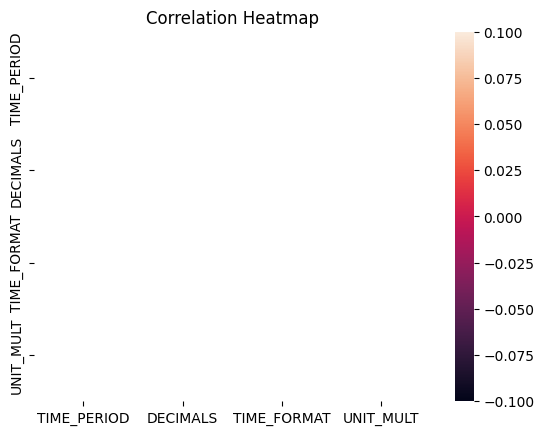

In [48]:
sns.heatmap(corr, annot=True)

plt.title("Correlation Heatmap")

plt.show()

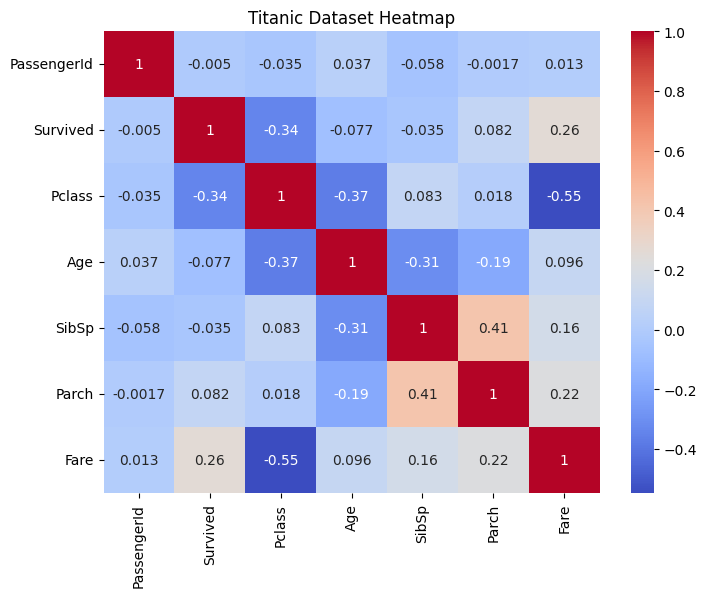

In [49]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = df.corr(numeric_only=True)

plt.figure(figsize=(8,6))

sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.title("Titanic Dataset Heatmap")

plt.show()

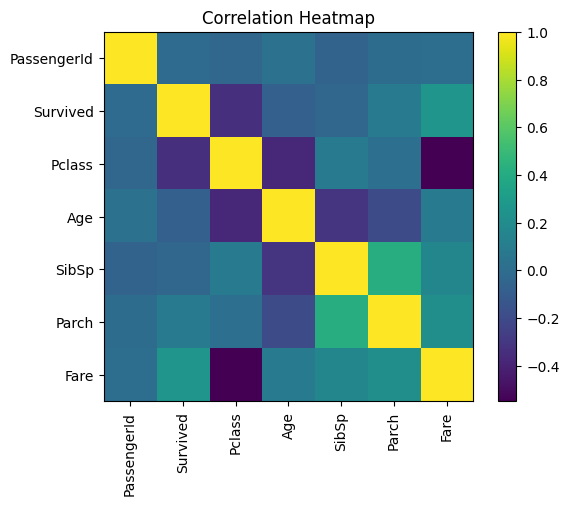

In [50]:
import matplotlib.pyplot as plt
import numpy as np

# create correlation matrix
corr = df.corr(numeric_only=True)

# plot heatmap
plt.imshow(corr)

plt.colorbar()  # shows color scale
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.title("Correlation Heatmap")

plt.show()